<a href="https://colab.research.google.com/github/braaaaayaaaaan/6001CMD_Assignment/blob/main/6001CMD_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **3.0 Critical Analysis of Data Quality**

# **Setting up the Environment**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42

# **Import the Dataset (flights.csv)**

In [ ]:
from google.colab import drive

# the flights.csv file is stored and mounted from google drive
drive.mount("/content/drive")

FILE_PATH = "/content/drive/MyDrive/Machine Learning Dataset/flights.csv"

df = pd.read_csv(FILE_PATH)

print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_11495/3891741412.py:7: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE_PATH)


Rows:    5,819,079
Columns: 31


# **Establishing the Dataset Structure**

In [ ]:
print("Dataset Dimensions:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(
    pd.DataFrame({
        "Feature": df.columns,
        "Data Type": df.dtypes.astype(str).values
    })
)

memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"\nApproximate Memory Usage: {memory_mb:,.2f} MB")

Dataset Dimensions:
(5819079, 31)

Column Names:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

Data Types:


,Feature,Data Type
0,YEAR,int64
1,MONTH,int64
2,DAY,int64
3,DAY_OF_WEEK,int64
4,AIRLINE,object
5,FLIGHT_NUMBER,int64
6,TAIL_NUMBER,object
7,ORIGIN_AIRPORT,object
8,DESTINATION_AIRPORT,object
9,SCHEDULED_DEPARTURE,int64



Approximate Memory Usage: 2,484.59 MB


In [ ]:
display(df.head())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,"2,354.000",-11.000,21.000,15.000,205.000,194.000,169.000,1448,404.000,4.000,430,408.000,-22.000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.000,-8.000,12.000,14.000,280.000,279.000,263.000,2330,737.000,4.000,750,741.000,-9.000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.000,-2.000,16.000,34.000,286.000,293.000,266.000,2296,800.000,11.000,806,811.000,5.000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.000,-5.000,15.000,30.000,285.000,281.000,258.000,2342,748.000,8.000,805,756.000,-9.000,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.000,-1.000,11.000,35.000,235.000,215.000,199.000,1448,254.000,5.000,320,259.000,-21.000,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,"5,819,079.000",NaN,NaN,NaN,"2,015.000",0.000,"2,015.000","2,015.000","2,015.000","2,015.000","2,015.000"
MONTH,"5,819,079.000",NaN,NaN,NaN,6.524,3.405,1.000,4.000,7.000,9.000,12.000
DAY,"5,819,079.000",NaN,NaN,NaN,15.705,8.783,1.000,8.000,16.000,23.000,31.000
DAY_OF_WEEK,"5,819,079.000",NaN,NaN,NaN,3.927,1.989,1.000,2.000,4.000,6.000,7.000
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,"5,819,079.000",NaN,NaN,NaN,"2,173.093","1,757.064",1.000,730.000,"1,690.000","3,230.000","9,855.000"
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,930,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,930,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,"5,819,079.000",NaN,NaN,NaN,"1,329.602",483.752,1.000,917.000,"1,325.000","1,730.000","2,359.000"


# **3.1 Missing Values and Record Completeness**

# **Missing Value Summary for All Features**

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": df.isna().mean() * 100
})

missing_summary["Non-Missing Count"] = (
    len(df) - missing_summary["Missing Count"]
)

missing_summary = (
    missing_summary
    .sort_values("Missing Percentage", ascending=False)
)

display(missing_summary)

,Missing Count,Missing Percentage,Non-Missing Count
CANCELLATION_REASON,5729195,98.455,89884
LATE_AIRCRAFT_DELAY,4755640,81.725,1063439
WEATHER_DELAY,4755640,81.725,1063439
AIRLINE_DELAY,4755640,81.725,1063439
AIR_SYSTEM_DELAY,4755640,81.725,1063439
SECURITY_DELAY,4755640,81.725,1063439
ELAPSED_TIME,105071,1.806,5714008
AIR_TIME,105071,1.806,5714008
ARRIVAL_DELAY,105071,1.806,5714008
WHEELS_ON,92513,1.590,5726566


In [ ]:
missing_only = missing_summary[
    missing_summary["Missing Count"] > 0
].copy()

display(missing_only)

,Missing Count,Missing Percentage,Non-Missing Count
CANCELLATION_REASON,5729195,98.455,89884
LATE_AIRCRAFT_DELAY,4755640,81.725,1063439
WEATHER_DELAY,4755640,81.725,1063439
AIRLINE_DELAY,4755640,81.725,1063439
AIR_SYSTEM_DELAY,4755640,81.725,1063439
SECURITY_DELAY,4755640,81.725,1063439
ELAPSED_TIME,105071,1.806,5714008
AIR_TIME,105071,1.806,5714008
ARRIVAL_DELAY,105071,1.806,5714008
WHEELS_ON,92513,1.590,5726566


# **Visualising the Missing Values**

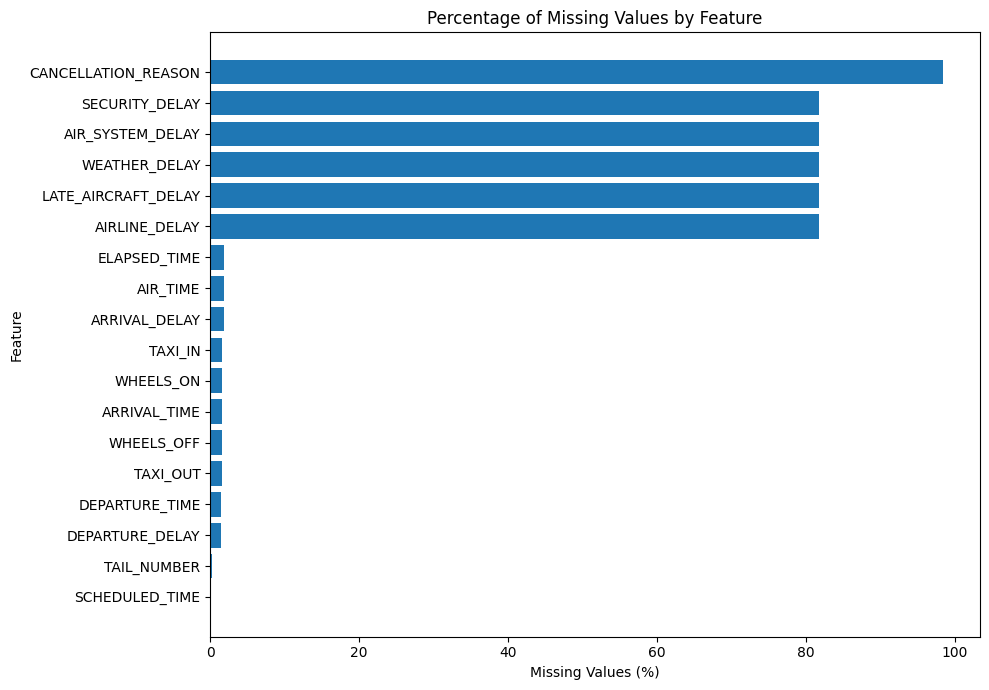

In [ ]:
missing_plot = (
    missing_only["Missing Percentage"]
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    missing_plot.index,
    missing_plot.values
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Percentage of Missing Values by Feature")

plt.tight_layout()
plt.show()

# **Investigating ARRIVAL_DELAY**

In [ ]:
arrival_delay_missing = df["ARRIVAL_DELAY"].isna()

print(
    f"Missing ARRIVAL_DELAY Records: "
    f"{arrival_delay_missing.sum():,}"
)

print(
    f"Missing Percentage: "
    f"{arrival_delay_missing.mean() * 100:.3f}%"
)

Missing ARRIVAL_DELAY Records: 105,071
Missing Percentage: 1.806%


In [ ]:
arrival_missing_by_status = (
    df
    .assign(
        ARRIVAL_DELAY_MISSING=df["ARRIVAL_DELAY"].isna()
    )
    .groupby(
        ["CANCELLED", "DIVERTED"],
        dropna=False
    )["ARRIVAL_DELAY_MISSING"]
    .agg(
        Total_Records="size",
        Missing_Count="sum",
        Missing_Rate="mean"
    )
    .reset_index()
)

arrival_missing_by_status["Missing_Rate"] *= 100

display(arrival_missing_by_status)

,CANCELLED,DIVERTED,Total_Records,Missing_Count,Missing_Rate
0,0,0,5714008,0,0.000
1,0,1,15187,15187,100.000
2,1,0,89884,89884,100.000


# **Overview of Flight Status Groups**

In [ ]:
conditions = [
    (df["CANCELLED"] == 1),
    (df["DIVERTED"] == 1)
]

choices = [
    "Cancelled",
    "Diverted"
]

flight_status = np.select(
    conditions,
    choices,
    default="Completed / Non-diverted"
)

arrival_missing_status = (
    pd.DataFrame({
        "Flight Status": flight_status,
        "ARRIVAL_DELAY Missing": df["ARRIVAL_DELAY"].isna()
    })
    .groupby("Flight Status")
    .agg(
        Total_Records=("ARRIVAL_DELAY Missing", "size"),
        Missing_ARRIVAL_DELAY=("ARRIVAL_DELAY Missing", "sum")
    )
)

arrival_missing_status["Missing Percentage"] = (
    arrival_missing_status["Missing_ARRIVAL_DELAY"]
    / arrival_missing_status["Total_Records"]
    * 100
)

display(arrival_missing_status)

,Total_Records,Missing_ARRIVAL_DELAY,Missing Percentage
Flight Status,,,
Cancelled,89884,89884,100.000
Completed / Non-diverted,5714008,0,0.000
Diverted,15187,15187,100.000


# **Visualising the Pattern**

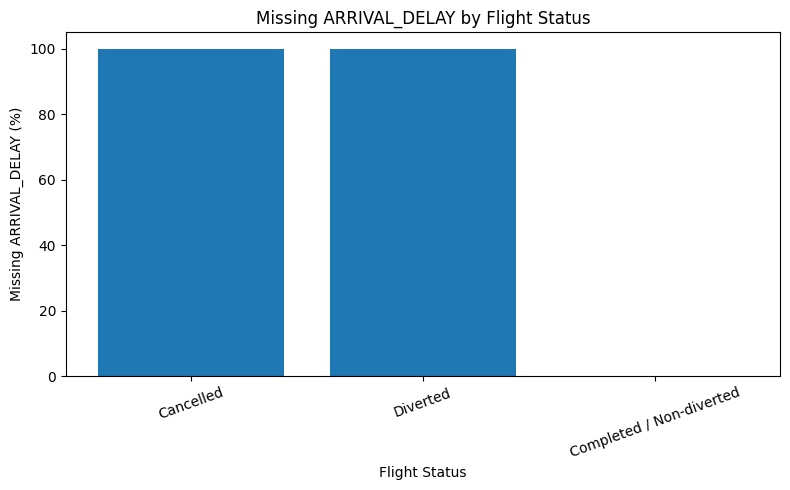

In [ ]:
status_plot = (
    arrival_missing_status["Missing Percentage"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    status_plot.index,
    status_plot.values
)

plt.ylabel("Missing ARRIVAL_DELAY (%)")
plt.xlabel("Flight Status")
plt.title("Missing ARRIVAL_DELAY by Flight Status")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

# **Investigating Structurally Missing Fields**

In [ ]:
structural_missing_cols = [
    "CANCELLATION_REASON",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

structural_missing_cols = [
    col for col in structural_missing_cols
    if col in df.columns
]

structural_missing_summary = missing_summary.loc[
    structural_missing_cols
]

display(structural_missing_summary)

,Missing Count,Missing Percentage,Non-Missing Count
CANCELLATION_REASON,5729195,98.455,89884
AIR_SYSTEM_DELAY,4755640,81.725,1063439
SECURITY_DELAY,4755640,81.725,1063439
AIRLINE_DELAY,4755640,81.725,1063439
LATE_AIRCRAFT_DELAY,4755640,81.725,1063439
WEATHER_DELAY,4755640,81.725,1063439


In [ ]:
if "CANCELLATION_REASON" in df.columns:

    cancellation_reason_check = (
        df
        .assign(
            REASON_MISSING=df["CANCELLATION_REASON"].isna()
        )
        .groupby("CANCELLED")["REASON_MISSING"]
        .agg(
            Total_Records="size",
            Missing_Count="sum",
            Missing_Rate="mean"
        )
        .reset_index()
    )

    cancellation_reason_check["Missing_Rate"] *= 100

    display(cancellation_reason_check)

,CANCELLED,Total_Records,Missing_Count,Missing_Rate
0,0,5729195,5729195,100.000
1,1,89884,0,0.000


In [ ]:
delay_cause_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

delay_cause_cols = [
    col for col in delay_cause_cols
    if col in df.columns
]

if delay_cause_cols:

    delay_cause_analysis = []

    for col in delay_cause_cols:

        delay_cause_analysis.append({
            "Feature": col,
            "Missing Count": df[col].isna().sum(),
            "Missing Percentage": df[col].isna().mean() * 100,
            "Zero Count": (df[col] == 0).sum(),
            "Positive Count": (df[col] > 0).sum()
        })

    delay_cause_analysis = pd.DataFrame(
        delay_cause_analysis
    )

    display(delay_cause_analysis)

,Feature,Missing Count,Missing Percentage,Zero Count,Positive Count
0,AIR_SYSTEM_DELAY,4755640,81.725,498613,564826
1,SECURITY_DELAY,4755640,81.725,1059955,3484
2,AIRLINE_DELAY,4755640,81.725,493417,570022
3,LATE_AIRCRAFT_DELAY,4755640,81.725,506486,556953
4,WEATHER_DELAY,4755640,81.725,998723,64716


# **3.2 Duplicate Records and Record-Level Consistency**

In [ ]:
exact_duplicate_mask = df.duplicated(keep=False)

exact_duplicate_rows = exact_duplicate_mask.sum()

duplicate_groups_excess = df.duplicated().sum()

print(f"Rows involved in Duplicate Groups: {exact_duplicate_rows:,}")
print(f"Excess Exact Duplicate Records:    {duplicate_groups_excess:,}")
print(
    f"Duplicate Percentage: "
    f"{duplicate_groups_excess / len(df) * 100:.6f}%"
)

Rows involved in Duplicate Groups: 0
Excess exact Duplicate Records:    0
Duplicate Percentage: 0.000000%


In [ ]:
if exact_duplicate_rows > 0:
    display(
        df[exact_duplicate_mask]
        .sort_values(list(df.columns))
        .head(20)
    )

In [ ]:
flight_key_candidates = [
    "YEAR",
    "MONTH",
    "DAY",
    "AIRLINE",
    "FLIGHT_NUMBER",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE"
]

flight_key = [
    col for col in flight_key_candidates
    if col in df.columns
]

key_duplicate_mask = df.duplicated(
    subset=flight_key,
    keep=False
)

print(
    f"Rows Sharing the Proposed Flight-Instance Key: "
    f"{key_duplicate_mask.sum():,}"
)

Rows Sharing the Proposed Flight-Instance Key: 0


In [ ]:
if key_duplicate_mask.sum() > 0:

    display(
        df.loc[
            key_duplicate_mask,
            flight_key
        ]
        .sort_values(flight_key)
        .head(30)
    )

# **3.3 Feature Distributions, Skewness and Outliers**

# **Establishing the Modelling Population**

In [ ]:
valid_flights = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARRIVAL_DELAY"].notna())
].copy()

print(f"Valid Flight Records: {len(valid_flights):,}")

Valid Flight Records: 5,714,008


# **Checking if SCHEDULED_TIME has Missing Values**

In [ ]:
selected_features = [
    "DISTANCE",
    "SCHEDULED_TIME",
    "ARRIVAL_DELAY"
]

remaining_missing = pd.DataFrame({
    "Feature": selected_features,
    "Missing Count": [
        valid_flights[col].isna().sum()
        for col in selected_features
    ]
})

remaining_missing["Missing Percentage"] = (
    remaining_missing["Missing Count"]
    / len(valid_flights)
    * 100
)

display(remaining_missing)

,Feature,Missing Count,Missing Percentage
0,DISTANCE,0,0.000
1,SCHEDULED_TIME,0,0.000
2,ARRIVAL_DELAY,0,0.000


# **Statistical Table**

In [ ]:
distribution_summary = (
    valid_flights[
        ["DISTANCE", "SCHEDULED_TIME", "ARRIVAL_DELAY"]
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
)

distribution_summary["Skewness"] = (
    valid_flights[
        ["DISTANCE", "SCHEDULED_TIME", "ARRIVAL_DELAY"]
    ]
    .skew()
)

distribution_summary = distribution_summary[
    [
        "count",
        "mean",
        "50%",
        "std",
        "min",
        "25%",
        "75%",
        "95%",
        "99%",
        "max",
        "Skewness"
    ]
]

distribution_summary = distribution_summary.rename(
    columns={
        "count": "Count",
        "mean": "Mean",
        "50%": "Median",
        "std": "Std. Dev.",
        "min": "Minimum",
        "25%": "Q1",
        "75%": "Q3",
        "95%": "95th Percentile",
        "99%": "99th Percentile",
        "max": "Maximum"
    }
)

display(distribution_summary.round(3))

,Count,Mean,Median,Std. Dev.,Minimum,Q1,Q3,95th Percentile,99th Percentile,Maximum,Skewness
DISTANCE,"5,714,008.000",824.457,650.000,608.662,31.000,373.000,"1,065.000","2,239.000","2,588.000","4,983.000",1.418
SCHEDULED_TIME,"5,714,008.000",141.894,123.000,75.314,18.000,85.000,174.000,309.000,377.000,718.000,1.341
ARRIVAL_DELAY,"5,714,008.000",4.407,-5.000,39.271,-87.000,-13.000,8.000,66.000,167.000,"1,971.000",6.503


# **Outlier Results**

In [ ]:
outlier_results = []

for feature in [
    "DISTANCE",
    "SCHEDULED_TIME",
    "ARRIVAL_DELAY"
]:

    values = valid_flights[feature].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outlier_mask = (
        (values < lower_bound) |
        (values > upper_bound)
    )

    outlier_results.append({
        "Feature": feature,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_mask.sum(),
        "Outlier Percentage":
            outlier_mask.mean() * 100
    })

outlier_summary = pd.DataFrame(
    outlier_results
)

display(outlier_summary.round(3))

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,DISTANCE,-665.000,"2,103.000",345365,6.044
1,SCHEDULED_TIME,-48.500,307.500,289411,5.065
2,ARRIVAL_DELAY,-44.500,39.500,512002,8.960


# **Visualising the Variables**

In [ ]:
plot_sample = valid_flights.sample(
    n=min(100000, len(valid_flights)),
    random_state=42
)

# **Distribution of Flight Distance**

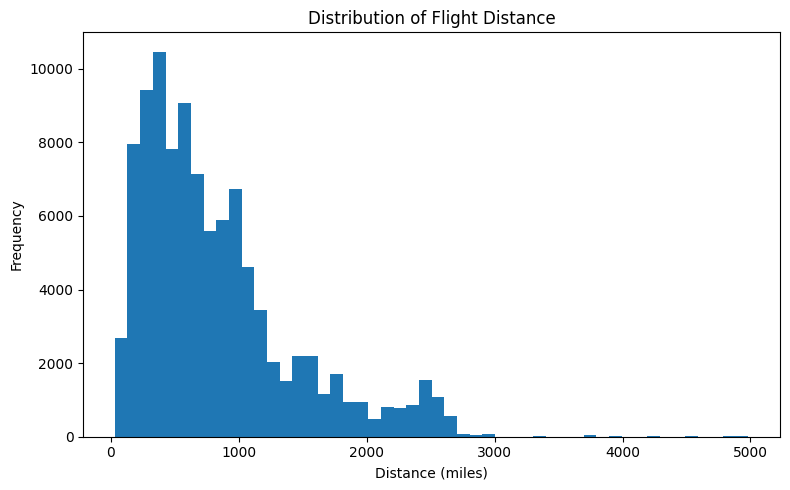

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    plot_sample["DISTANCE"].dropna(),
    bins=50
)

plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")
plt.title("Distribution of Flight Distance")

plt.tight_layout()
plt.show()

# **Distribution of Scheduled Time**

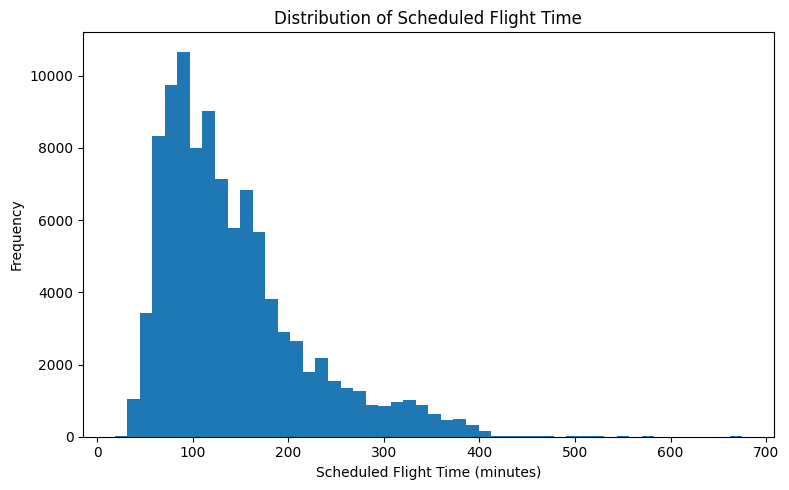

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    plot_sample["SCHEDULED_TIME"].dropna(),
    bins=50
)

plt.xlabel("Scheduled Flight Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Scheduled Flight Time")

plt.tight_layout()
plt.show()

# **Distribution of ARRIVAL_DELAY**

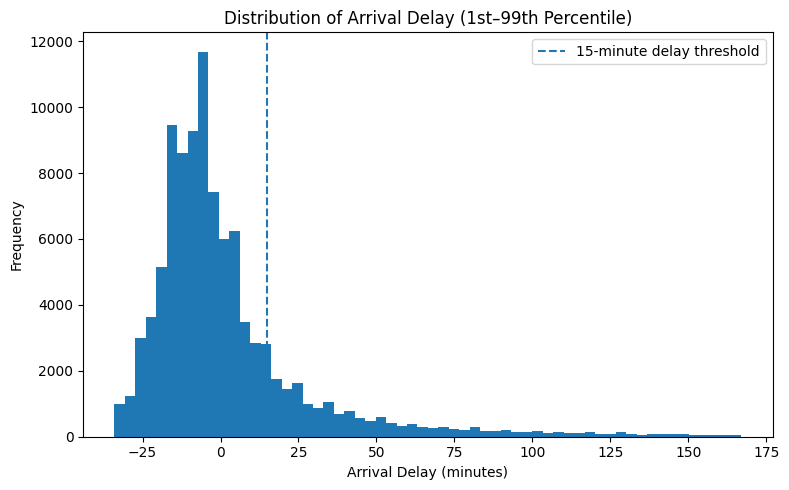

In [ ]:
lower_limit = (
    valid_flights["ARRIVAL_DELAY"]
    .quantile(0.01)
)

upper_limit = (
    valid_flights["ARRIVAL_DELAY"]
    .quantile(0.99)
)

arrival_plot = plot_sample[
    plot_sample["ARRIVAL_DELAY"].between(
        lower_limit,
        upper_limit
    )
]

plt.figure(figsize=(8, 5))

plt.hist(
    arrival_plot["ARRIVAL_DELAY"],
    bins=60
)

plt.axvline(
    15,
    linestyle="--",
    label="15-minute delay threshold"
)

plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Arrival Delay "
    "(1st–99th Percentile)"
)

plt.legend()

plt.tight_layout()
plt.show()

# **Investigating Outliers**

In [ ]:
plausibility_summary = pd.DataFrame({
    "Validation Check": [
        "DISTANCE <= 0",
        "SCHEDULED_TIME <= 0"
    ],

    "Records": [
        (valid_flights["DISTANCE"] <= 0).sum(),
        (valid_flights["SCHEDULED_TIME"] <= 0).sum()
    ]
})

display(plausibility_summary)

,Validation Check,Records
0,DISTANCE <= 0,0
1,SCHEDULED_TIME <= 0,0


In [ ]:
display(
    valid_flights[
        [
            "AIRLINE",
            "ORIGIN_AIRPORT",
            "DESTINATION_AIRPORT",
            "DISTANCE",
            "SCHEDULED_TIME",
            "ARRIVAL_DELAY"
        ]
    ]
    .nlargest(
        10,
        "DISTANCE"
    )
)

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME,ARRIVAL_DELAY
2253,DL,JFK,HNL,4983,718.000,-6.000
2960,HA,JFK,HNL,4983,675.000,-17.000
9394,HA,HNL,JFK,4983,570.000,3.000
10134,DL,HNL,JFK,4983,585.000,-20.000
17541,DL,JFK,HNL,4983,718.000,-8.000
18335,HA,JFK,HNL,4983,675.000,39.000
25298,HA,HNL,JFK,4983,570.000,15.000
26113,DL,HNL,JFK,4983,585.000,-2.000
34018,DL,JFK,HNL,4983,718.000,13.000
34755,HA,JFK,HNL,4983,675.000,34.000


In [ ]:
display(
    valid_flights[
        [
            "AIRLINE",
            "ORIGIN_AIRPORT",
            "DESTINATION_AIRPORT",
            "DISTANCE",
            "SCHEDULED_TIME",
            "ARRIVAL_DELAY"
        ]
    ]
    .nlargest(
        10,
        "ARRIVAL_DELAY"
    )
)

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME,ARRIVAL_DELAY
337720,AA,BHM,DFW,597,134.000,"1,971.000"
3412085,AA,RIC,DFW,1158,185.000,"1,898.000"
4103531,AA,SAN,DFW,1171,179.000,"1,665.000"
5279939,AA,DTW,ORD,235,82.000,"1,638.000"
3100911,AA,IND,LAX,1814,268.000,"1,636.000"
5810811,AA,ABQ,DFW,569,104.000,"1,636.000"
886984,AA,STL,MIA,1068,168.000,"1,627.000"
1278418,AA,OMA,DFW,583,112.000,"1,598.000"
264495,AA,LAS,LAX,236,76.000,"1,593.000"
949876,AA,HNL,LAX,2556,327.000,"1,576.000"


In [ ]:
extreme_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DISTANCE",
    "SCHEDULED_TIME"
]

print("Longest-Distance Flights")
display(
    valid_flights[extreme_features]
    .nlargest(10, "DISTANCE")
)

print("\nLongest Scheduled Flight Times")
display(
    valid_flights[extreme_features]
    .nlargest(10, "SCHEDULED_TIME")
)

Longest-Distance Flights


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME
2253,DL,JFK,HNL,4983,718.000
2960,HA,JFK,HNL,4983,675.000
9394,HA,HNL,JFK,4983,570.000
10134,DL,HNL,JFK,4983,585.000
17541,DL,JFK,HNL,4983,718.000
18335,HA,JFK,HNL,4983,675.000
25298,HA,HNL,JFK,4983,570.000
26113,DL,HNL,JFK,4983,585.000
34018,DL,JFK,HNL,4983,718.000
34755,HA,JFK,HNL,4983,675.000



Longest Scheduled Flight Times


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME
2253,DL,JFK,HNL,4983,718.000
17541,DL,JFK,HNL,4983,718.000
34018,DL,JFK,HNL,4983,718.000
49513,DL,JFK,HNL,4983,718.000
66059,DL,JFK,HNL,4983,718.000
82395,DL,JFK,HNL,4983,718.000
97676,DL,JFK,HNL,4983,718.000
129324,DL,JFK,HNL,4983,718.000
144699,DL,JFK,HNL,4983,718.000
156715,DL,JFK,HNL,4983,718.000


In [ ]:
delay_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DISTANCE",
    "SCHEDULED_TIME",
    "ARRIVAL_DELAY"
]

print("Largest Arrival Delays")
display(
    valid_flights[delay_features]
    .nlargest(10, "ARRIVAL_DELAY")
)

Largest Arrival Delays


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_TIME,ARRIVAL_DELAY
337720,AA,BHM,DFW,597,134.000,"1,971.000"
3412085,AA,RIC,DFW,1158,185.000,"1,898.000"
4103531,AA,SAN,DFW,1171,179.000,"1,665.000"
5279939,AA,DTW,ORD,235,82.000,"1,638.000"
3100911,AA,IND,LAX,1814,268.000,"1,636.000"
5810811,AA,ABQ,DFW,569,104.000,"1,636.000"
886984,AA,STL,MIA,1068,168.000,"1,627.000"
1278418,AA,OMA,DFW,583,112.000,"1,598.000"
264495,AA,LAS,LAX,236,76.000,"1,593.000"
949876,AA,HNL,LAX,2556,327.000,"1,576.000"


In [ ]:
extreme_delay_check_columns = [
    "AIRLINE",
    "FLIGHT_NUMBER",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_TIME",
    "DEPARTURE_DELAY",
    "SCHEDULED_ARRIVAL",
    "ARRIVAL_TIME",
    "ARRIVAL_DELAY",
    "CANCELLED",
    "DIVERTED"
]

display(
    valid_flights[extreme_delay_check_columns]
    .nlargest(10, "ARRIVAL_DELAY")
)

,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,CANCELLED,DIVERTED
337720,AA,1322,BHM,DFW,700,"1,608.000","1,988.000",914,"1,805.000","1,971.000",0,0
3412085,AA,96,RIC,DFW,709,"1,427.000","1,878.000",914,"1,652.000","1,898.000",0,0
4103531,AA,1063,SAN,DFW,700,"1,050.000","1,670.000",1159,"1,544.000","1,665.000",0,0
5279939,AA,2559,DTW,ORD,1027,"1,338.000","1,631.000",1049,"1,407.000","1,638.000",0,0
3100911,AA,1319,IND,LAX,1905,"2,210.000","1,625.000",2033,"2,349.000","1,636.000",0,0
5810811,AA,2214,ABQ,DFW,1041,"1,410.000","1,649.000",1325,"1,641.000","1,636.000",0,0
886984,AA,1312,STL,MIA,620,847.000,"1,587.000",1008,"1,315.000","1,627.000",0,0
1278418,AA,1279,OMA,DFW,1103,"1,352.000","1,609.000",1255,"1,533.000","1,598.000",0,0
264495,AA,224,LAS,LAX,1130,"1,414.000","1,604.000",1246,"1,519.000","1,593.000",0,0
949876,AA,270,HNL,LAX,828,"1,057.000","1,589.000",1555,"1,811.000","1,576.000",0,0


# **3.4 Feature Relationships, Correlation, and Leakage Risk**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Selecting Meaningful Quantitative Variables**

In [ ]:
corr_features = [
    "DISTANCE",
    "SCHEDULED_TIME",
    "DEPARTURE_DELAY",
    "TAXI_OUT",
    "ELAPSED_TIME",
    "AIR_TIME",
    "TAXI_IN",
    "ARRIVAL_DELAY"
]

corr_df = df[corr_features].copy()

corr_df.head()

,DISTANCE,SCHEDULED_TIME,DEPARTURE_DELAY,TAXI_OUT,ELAPSED_TIME,AIR_TIME,TAXI_IN,ARRIVAL_DELAY
0,1448,205.000,-11.000,21.000,194.000,169.000,4.000,-22.000
1,2330,280.000,-8.000,12.000,279.000,263.000,4.000,-9.000
2,2296,286.000,-2.000,16.000,293.000,266.000,11.000,5.000
3,2342,285.000,-5.000,15.000,281.000,258.000,8.000,-9.000
4,1448,235.000,-1.000,11.000,215.000,199.000,5.000,-21.000


# **Pearson Correlation Matrix**

In [ ]:
corr_matrix = corr_df.corr(method="pearson")

corr_matrix.round(3)

,DISTANCE,SCHEDULED_TIME,DEPARTURE_DELAY,TAXI_OUT,ELAPSED_TIME,AIR_TIME,TAXI_IN,ARRIVAL_DELAY
DISTANCE,1.000,0.984,0.024,0.072,0.974,0.986,0.075,-0.025
SCHEDULED_TIME,0.984,1.000,0.028,0.112,0.985,0.991,0.099,-0.030
DEPARTURE_DELAY,0.024,0.028,1.000,0.059,0.031,0.023,0.013,0.945
TAXI_OUT,0.072,0.112,0.059,1.000,0.205,0.088,0.003,0.227
ELAPSED_TIME,0.974,0.985,0.031,0.205,1.000,0.990,0.156,0.029
AIR_TIME,0.986,0.991,0.023,0.088,0.990,1.000,0.082,-0.007
TAXI_IN,0.075,0.099,0.013,0.003,0.156,0.082,1.000,0.117
ARRIVAL_DELAY,-0.025,-0.030,0.945,0.227,0.029,-0.007,0.117,1.000


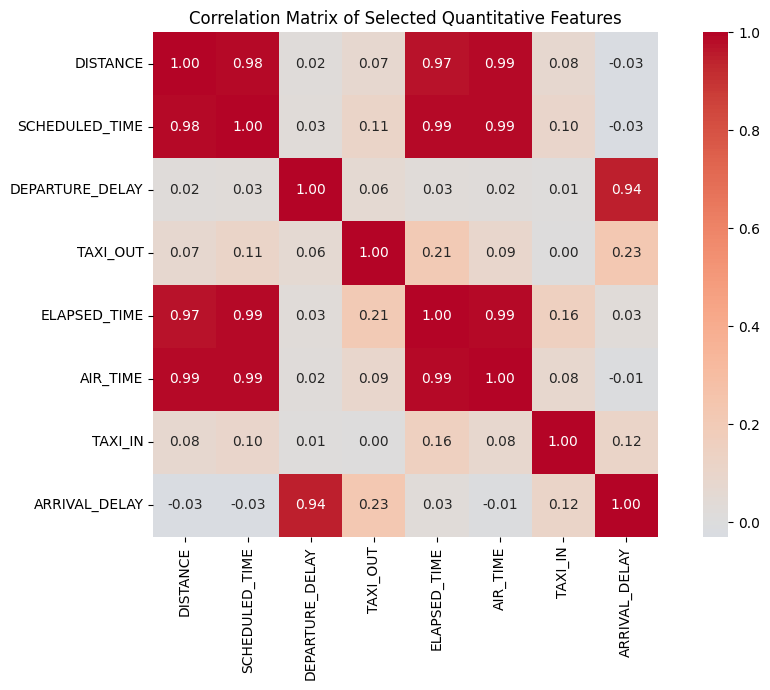

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Selected Quantitative Features")
plt.tight_layout()
plt.show()

# **Rank Relationships with ARRIVAL_DELAY**

In [ ]:
arrival_delay_corr = (
    corr_matrix["ARRIVAL_DELAY"]
    .drop("ARRIVAL_DELAY")
    .sort_values(key=abs, ascending=False)
)

arrival_delay_corr.to_frame("Correlation with ARRIVAL_DELAY").round(3)

,Correlation with ARRIVAL_DELAY
DEPARTURE_DELAY,0.945
TAXI_OUT,0.227
TAXI_IN,0.117
SCHEDULED_TIME,-0.030
ELAPSED_TIME,0.029
DISTANCE,-0.025
AIR_TIME,-0.007


# **Assess Prediction-Time Availability**

In [ ]:
feature_availability = pd.DataFrame({
    "Feature": [
        "DISTANCE",
        "SCHEDULED_TIME",
        "DEPARTURE_DELAY",
        "TAXI_OUT",
        "ELAPSED_TIME",
        "AIR_TIME",
        "TAXI_IN"
    ],

    "Available_Before_Departure": [
        True,
        True,
        False,
        False,
        False,
        False,
        False
    ],

    "Reason": [
        "Known from the planned route before departure",
        "Known from the published flight schedule",
        "Only known when actual departure timing is observed",
        "Occurs after the aircraft begins departure operations",
        "Known only after the flight journey is completed",
        "Measured during the flight",
        "Occurs during arrival operations"
    ]
})

feature_availability

,Feature,Available_Before_Departure,Reason
0,DISTANCE,True,Known from the planned route before departure
1,SCHEDULED_TIME,True,Known from the published flight schedule
2,DEPARTURE_DELAY,False,Only known when actual departure timing is obs...
3,TAXI_OUT,False,Occurs after the aircraft begins departure ope...
4,ELAPSED_TIME,False,Known only after the flight journey is completed
5,AIR_TIME,False,Measured during the flight
6,TAXI_IN,False,Occurs during arrival operations


In [ ]:
target_corr = (
    corr_matrix["ARRIVAL_DELAY"]
    .drop("ARRIVAL_DELAY")
    .rename("Correlation_with_ARRIVAL_DELAY")
)

feature_assessment = feature_availability.merge(
    target_corr,
    left_on="Feature",
    right_index=True,
    how="left"
)

feature_assessment["Correlation_with_ARRIVAL_DELAY"] = (
    feature_assessment["Correlation_with_ARRIVAL_DELAY"].round(3)
)

feature_assessment

,Feature,Available_Before_Departure,Reason,Correlation_with_ARRIVAL_DELAY
0,DISTANCE,True,Known from the planned route before departure,-0.025
1,SCHEDULED_TIME,True,Known from the published flight schedule,-0.030
2,DEPARTURE_DELAY,False,Only known when actual departure timing is obs...,0.945
3,TAXI_OUT,False,Occurs after the aircraft begins departure ope...,0.227
4,ELAPSED_TIME,False,Known only after the flight journey is completed,0.029
5,AIR_TIME,False,Measured during the flight,-0.007
6,TAXI_IN,False,Occurs during arrival operations,0.117


# **Testing Redundancy between DISTANCE AND SCHEDULED_TIME**

In [ ]:
distance_schedule_corr = df[
    ["DISTANCE", "SCHEDULED_TIME"]
].corr(method="pearson").iloc[0, 1]

print(
    f"Correlation between DISTANCE and SCHEDULED_TIME: "
    f"{distance_schedule_corr:.3f}"
)

Correlation between DISTANCE and SCHEDULED_TIME: 0.984


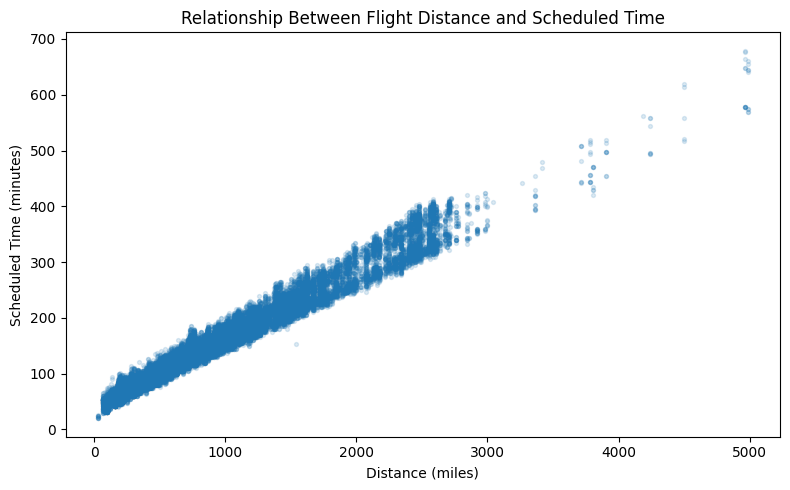

In [ ]:
plot_sample = (
    df[["DISTANCE", "SCHEDULED_TIME"]]
    .dropna()
    .sample(n=min(50000, len(df)), random_state=42)
)

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_sample["DISTANCE"],
    plot_sample["SCHEDULED_TIME"],
    alpha=0.15,
    s=8
)

plt.xlabel("Distance (miles)")
plt.ylabel("Scheduled Time (minutes)")
plt.title("Relationship Between Flight Distance and Scheduled Time")
plt.tight_layout()
plt.show()

# **Checking if Strong Target Correlations Come from Leakage Variables**

In [ ]:
leakage_candidates = [
    "DEPARTURE_DELAY",
    "TAXI_OUT",
    "ELAPSED_TIME",
    "AIR_TIME",
    "TAXI_IN"
]

leakage_summary = pd.DataFrame({
    "Feature": leakage_candidates,
    "Correlation_with_ARRIVAL_DELAY": [
        corr_matrix.loc[feature, "ARRIVAL_DELAY"]
        for feature in leakage_candidates
    ]
})

leakage_summary["Correlation_with_ARRIVAL_DELAY"] = (
    leakage_summary["Correlation_with_ARRIVAL_DELAY"].round(3)
)

leakage_summary = leakage_summary.sort_values(
    "Correlation_with_ARRIVAL_DELAY",
    key=abs,
    ascending=False
)

leakage_summary

,Feature,Correlation_with_ARRIVAL_DELAY
0,DEPARTURE_DELAY,0.945
1,TAXI_OUT,0.227
4,TAXI_IN,0.117
2,ELAPSED_TIME,0.029
3,AIR_TIME,-0.007


# **Delay-Cause Variables**

In [ ]:
delay_cause_features = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

delay_cause_corr = (
    df[delay_cause_features + ["ARRIVAL_DELAY"]]
    .corr(method="pearson")["ARRIVAL_DELAY"]
    .drop("ARRIVAL_DELAY")
    .sort_values(key=abs, ascending=False)
)

delay_cause_corr.to_frame(
    "Correlation with ARRIVAL_DELAY"
).round(3)

,Correlation with ARRIVAL_DELAY
AIRLINE_DELAY,0.609
LATE_AIRCRAFT_DELAY,0.522
WEATHER_DELAY,0.265
AIR_SYSTEM_DELAY,0.247
SECURITY_DELAY,0.010


# **Reference: Binary Target**

In [ ]:
analysis_df = df.copy()

analysis_df["DELAY_STATUS"] = np.where(
    analysis_df["ARRIVAL_DELAY"] >= 15,
    "Delayed",
    "Not Delayed"
)

analysis_df[["ARRIVAL_DELAY", "DELAY_STATUS"]].head()

,ARRIVAL_DELAY,DELAY_STATUS
0,-22.000,Not Delayed
1,-9.000,Not Delayed
2,5.000,Not Delayed
3,-9.000,Not Delayed
4,-21.000,Not Delayed


# **3.5 Target Distribution and Class Imbalance**

# **Temporary Diagnostic Target**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

valid_target_mask = (
    df["ARRIVAL_DELAY"].notna()
    & (df["CANCELLED"] == 0)
    & (df["DIVERTED"] == 0)
)

target_analysis = df.loc[
    valid_target_mask,
    ["ARRIVAL_DELAY"]
].copy()

target_analysis["DELAY_STATUS"] = np.where(
    target_analysis["ARRIVAL_DELAY"] >= 15,
    "Delayed",
    "Not Delayed"
)

print(f"Valid Records Analysed: {len(target_analysis):,}")

Valid Records Analysed: 5,714,008


# **Calculating the Counts and Percentages**

In [ ]:
class_counts = (
    target_analysis["DELAY_STATUS"]
    .value_counts()
    .reindex(["Not Delayed", "Delayed"])
)

class_percentages = (
    target_analysis["DELAY_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["Not Delayed", "Delayed"])
)

class_distribution = pd.DataFrame({
    "Count": class_counts,
    "Percentage (%)": class_percentages.round(2)
})

class_distribution

,Count,Percentage (%)
DELAY_STATUS,,
Not Delayed,4650569,81.390
Delayed,1063439,18.610


# **Calculating the Imbalance Ratio and Majority Baseline**

In [ ]:
majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count
majority_baseline = (majority_count / class_counts.sum()) * 100

print(f"Majority-to-Minority Ratio: {imbalance_ratio:.2f}:1")
print(f"Majority-Class Baseline Accuracy: {majority_baseline:.2f}%")

Majority-to-Minority Ratio: 4.37:1
Majority-Class Baseline Accuracy: 81.39%


# **Visualising the Results using Graph**

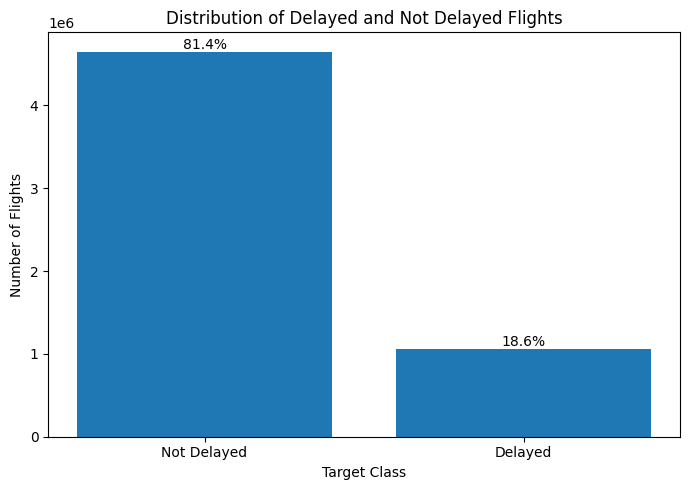

In [ ]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_distribution.index,
    class_distribution["Count"]
)

plt.xlabel("Target Class")
plt.ylabel("Number of Flights")
plt.title("Distribution of Delayed and Not Delayed Flights")

for bar, percentage in zip(
    bars,
    class_distribution["Percentage (%)"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# **3.6 Noise and Data Inconsistencies**

# **Check Basic Domain Validity**

In [ ]:
validity_checks = {
    "Invalid MONTH": ~df["MONTH"].between(1, 12),
    "Invalid DAY_OF_WEEK": ~df["DAY_OF_WEEK"].between(1, 7),
    "Non-positive DISTANCE": df["DISTANCE"] <= 0,
    "Non-positive SCHEDULED_TIME": df["SCHEDULED_TIME"] <= 0,
    "Negative AIR_TIME": df["AIR_TIME"] < 0,
    "Negative TAXI_OUT": df["TAXI_OUT"] < 0,
    "Negative TAXI_IN": df["TAXI_IN"] < 0,
    "Invalid CANCELLED flag": ~df["CANCELLED"].isin([0, 1]),
    "Invalid DIVERTED flag": ~df["DIVERTED"].isin([0, 1])
}

validity_summary = pd.DataFrame({
    "Check": validity_checks.keys(),
    "Invalid Records": [condition.sum() for condition in validity_checks.values()]
})

validity_summary["Percentage (%)"] = (
    validity_summary["Invalid Records"] / len(df) * 100
).round(4)

validity_summary

,Check,Invalid Records,Percentage (%)
0,Invalid MONTH,0,0.000
1,Invalid DAY_OF_WEEK,0,0.000
2,Non-positive DISTANCE,0,0.000
3,Non-positive SCHEDULED_TIME,0,0.000
4,Negative AIR_TIME,0,0.000
5,Negative TAXI_OUT,0,0.000
6,Negative TAXI_IN,0,0.000
7,Invalid CANCELLED flag,0,0.000
8,Invalid DIVERTED flag,0,0.000


# **Consistency of Operational Status**

In [ ]:
status_checks = {
    "Both CANCELLED and DIVERTED": (
        (df["CANCELLED"] == 1) &
        (df["DIVERTED"] == 1)
    ),

    "Cancelled flight with ARRIVAL_DELAY": (
        (df["CANCELLED"] == 1) &
        df["ARRIVAL_DELAY"].notna()
    ),

    "Diverted flight with ARRIVAL_DELAY": (
        (df["DIVERTED"] == 1) &
        df["ARRIVAL_DELAY"].notna()
    )
}

status_summary = pd.DataFrame({
    "Consistency Check": status_checks.keys(),
    "Records": [condition.sum() for condition in status_checks.values()]
})

status_summary["Percentage (%)"] = (
    status_summary["Records"] / len(df) * 100
).round(4)

status_summary

,Consistency Check,Records,Percentage (%)
0,Both CANCELLED and DIVERTED,0,0.000
1,Cancelled flight with ARRIVAL_DELAY,0,0.000
2,Diverted flight with ARRIVAL_DELAY,0,0.000


# **Checking Flight-Duration Components**

In [ ]:
duration_cols = [
    "ELAPSED_TIME",
    "TAXI_OUT",
    "AIR_TIME",
    "TAXI_IN"
]

duration_check = df[duration_cols].dropna().copy()

duration_check["CALCULATED_ELAPSED_TIME"] = (
    duration_check["TAXI_OUT"] +
    duration_check["AIR_TIME"] +
    duration_check["TAXI_IN"]
)

duration_check["ELAPSED_DIFFERENCE"] = (
    duration_check["ELAPSED_TIME"] -
    duration_check["CALCULATED_ELAPSED_TIME"]
)

duration_check["ELAPSED_DIFFERENCE"].describe()

,ELAPSED_DIFFERENCE
count,"5,714,008.000"
mean,0.000
std,0.000
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,0.000


In [ ]:
duration_inconsistent = (
    duration_check["ELAPSED_DIFFERENCE"].abs() > 1
)

print(
    f"Records with elapsed-time difference > 1 minute: "
    f"{duration_inconsistent.sum():,}"
)

print(
    f"Percentage: "
    f"{duration_inconsistent.mean() * 100:.4f}%"
)

Records with elapsed-time difference > 1 minute: 0
Percentage: 0.0000%
